In [1]:
library(ggplot2)
library(data.table)

In [2]:
meta = fread('/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz')

Warning message:
“Removed 6590 rows containing non-finite values (`stat_ydensity()`).”
Warning message:
“Removed 6590 rows containing non-finite values (`stat_boxplot()`).”
Warning message:
“Removed 6590 rows containing missing values (`geom_point()`).”


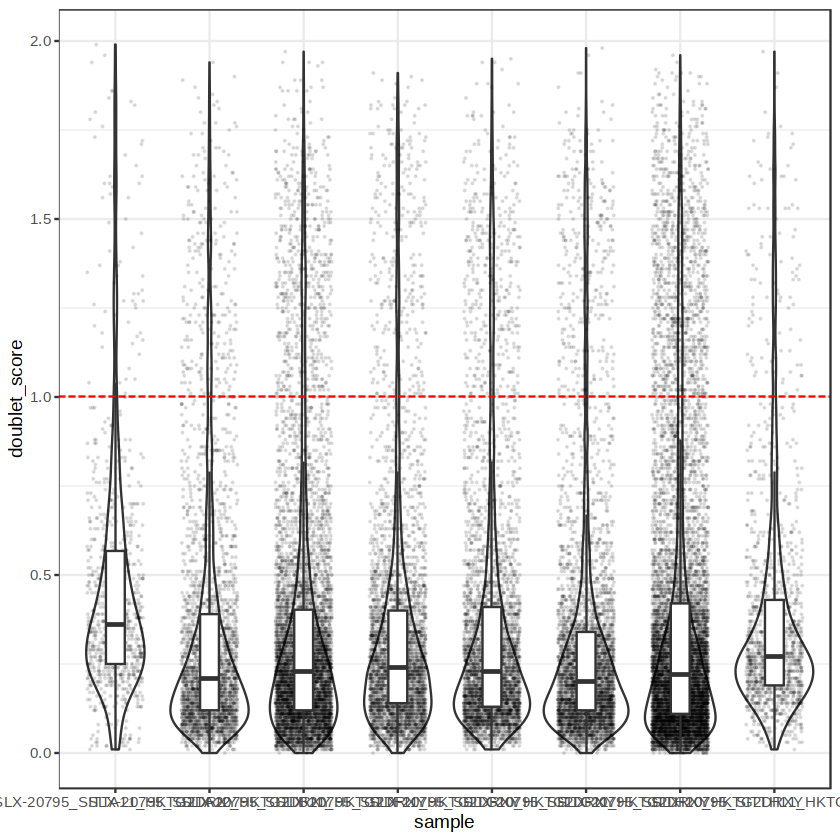

In [4]:
ggplot(meta, aes(sample, doublet_score)) + 
        geom_violin() + 
        geom_point(size=0.1, alpha=0.1, position = position_jitter(w = 0.3, h = 0)) + 
        geom_boxplot(width=0.2, outlier.shape=NA) + 
        geom_hline(yintercept=max(meta[doublet_call==FALSE, doublet_score]), linetype='longdash', color='red') + 
        theme_bw()

In [5]:
nrow(meta[tdTom != tdTom_corr])

[1] 1

In [3]:
head(meta)

cell,sample,barcode,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom,idx,tdTom_corr,pass_rnaQC,doublet_score,doublet_call
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<int>,<lgl>,<lgl>,<dbl>,<lgl>
SLX-20795_SITTA11_HKTG2DRXY#AAACCCAGTTCTCTAT-1,SLX-20795_SITTA11_HKTG2DRXY,AAACCCAGTTCTCTAT-1,5140,31003,1.80,25.11,E8.5,TRUE,1,TRUE,TRUE,0.16,FALSE
SLX-20795_SITTA11_HKTG2DRXY#AAACGCTAGTGATTCC-1,SLX-20795_SITTA11_HKTG2DRXY,AAACGCTAGTGATTCC-1,5119,28276,1.87,27.04,E8.5,TRUE,2,TRUE,TRUE,0.27,FALSE
SLX-20795_SITTA11_HKTG2DRXY#AAACGCTCATGACTCA-1,SLX-20795_SITTA11_HKTG2DRXY,AAACGCTCATGACTCA-1,5032,23751,1.29,22.55,E8.5,TRUE,3,TRUE,TRUE,0.24,FALSE
SLX-20795_SITTA11_HKTG2DRXY#AAAGGATGTAATGCGG-1,SLX-20795_SITTA11_HKTG2DRXY,AAAGGATGTAATGCGG-1,4944,20794,5.17,19.06,E8.5,TRUE,4,TRUE,FALSE,NA,NA
SLX-20795_SITTA11_HKTG2DRXY#AAAGGGCAGTCATGAA-1,SLX-20795_SITTA11_HKTG2DRXY,AAAGGGCAGTCATGAA-1,5562,40272,2.47,30.16,E8.5,TRUE,5,TRUE,TRUE,0.21,FALSE
SLX-20795_SITTA11_HKTG2DRXY#AAAGGTAAGCCTGCCA-1,SLX-20795_SITTA11_HKTG2DRXY,AAAGGTAAGCCTGCCA-1,5780,33907,2.05,27.02,E8.5,TRUE,6,TRUE,TRUE,0.38,FALSE


In [8]:
head(meta)

cell,sample,barcode,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom,idx,tdTom_corr,pass_rnaQC,doublet_score,doublet_call
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<int>,<lgl>,<lgl>,<dbl>,<lgl>
SLX-20795_SITTA11_HKTG2DRXY#AAACCCAGTTCTCTAT-1,SLX-20795_SITTA11_HKTG2DRXY,AAACCCAGTTCTCTAT-1,5140,31003,1.80,25.11,E8.5,TRUE,1,TRUE,TRUE,0.16,FALSE
SLX-20795_SITTA11_HKTG2DRXY#AAACGCTAGTGATTCC-1,SLX-20795_SITTA11_HKTG2DRXY,AAACGCTAGTGATTCC-1,5119,28276,1.87,27.04,E8.5,TRUE,2,TRUE,TRUE,0.27,FALSE
SLX-20795_SITTA11_HKTG2DRXY#AAACGCTCATGACTCA-1,SLX-20795_SITTA11_HKTG2DRXY,AAACGCTCATGACTCA-1,5032,23751,1.29,22.55,E8.5,TRUE,3,TRUE,TRUE,0.24,FALSE
SLX-20795_SITTA11_HKTG2DRXY#AAAGGATGTAATGCGG-1,SLX-20795_SITTA11_HKTG2DRXY,AAAGGATGTAATGCGG-1,4944,20794,5.17,19.06,E8.5,TRUE,4,TRUE,FALSE,NA,NA
SLX-20795_SITTA11_HKTG2DRXY#AAAGGGCAGTCATGAA-1,SLX-20795_SITTA11_HKTG2DRXY,AAAGGGCAGTCATGAA-1,5562,40272,2.47,30.16,E8.5,TRUE,5,TRUE,TRUE,0.21,FALSE
SLX-20795_SITTA11_HKTG2DRXY#AAAGGTAAGCCTGCCA-1,SLX-20795_SITTA11_HKTG2DRXY,AAAGGTAAGCCTGCCA-1,5780,33907,2.05,27.02,E8.5,TRUE,6,TRUE,TRUE,0.38,FALSE


Warning message:
“Removed 119 rows containing non-finite values (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_bar()`).”


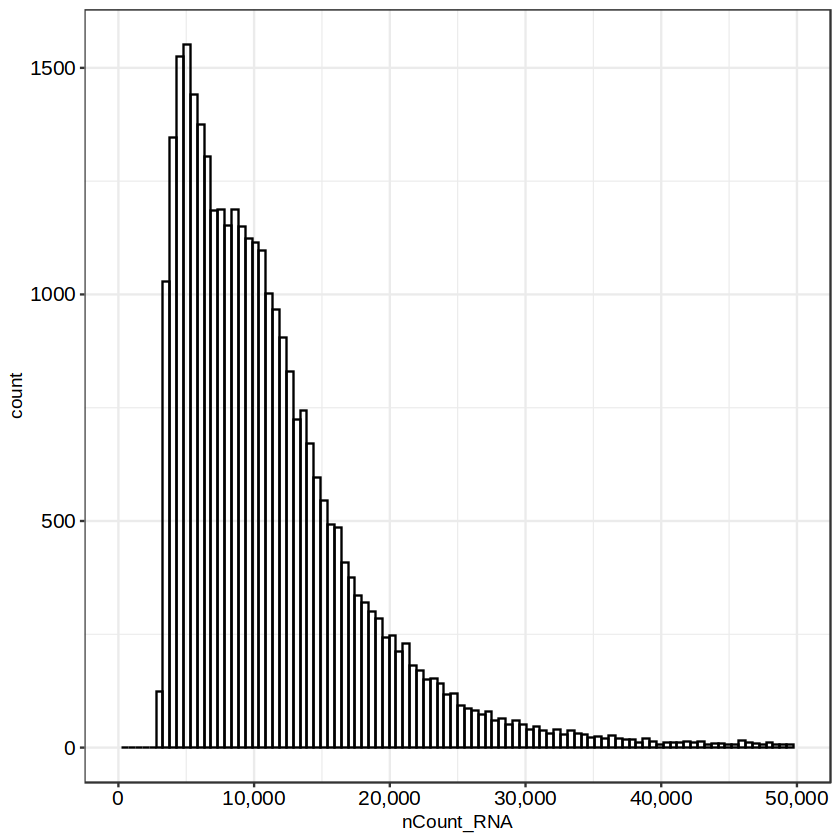

In [12]:
ggplot(meta[pass_rnaQC == T & doublet_call == FALSE], aes(nCount_RNA)) + 
    geom_histogram(fill = NA, color='black', bins = 100) + 
    scale_x_continuous(labels = scales::label_comma(), limits = c(0, 50000)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 12, color = 'black'))

Warning message:
“Removed 119 rows containing non-finite values (`stat_ydensity()`).”


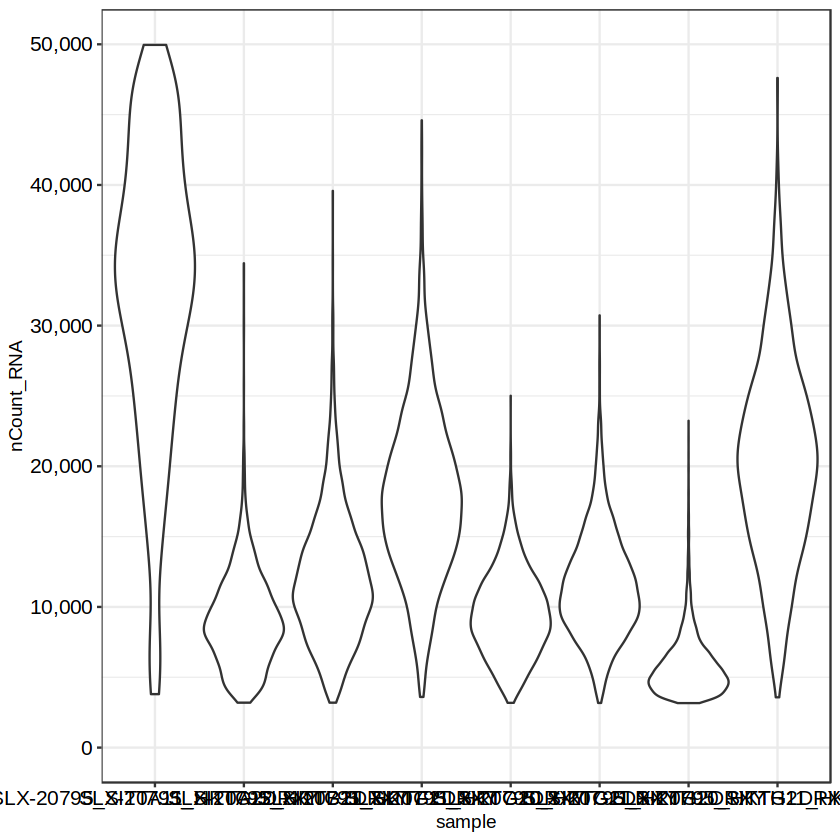

In [15]:
ggplot(meta[pass_rnaQC == T & doublet_call == FALSE], aes(sample, nCount_RNA)) + 
    geom_violin(scale = 'width') + 
    scale_y_continuous(labels = scales::label_comma(), limits = c(0, 50000)) + 
    theme_bw() + 
    theme(axis.text = element_text(size = 12, color = 'black'))